In [1]:
%load_ext autoreload
%autoreload 2

import frb_secondary as iso
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u

RUN_CONFIG = iso.AnalysisConfig(
    use_gal_mask=False,
    use_sel_func=False,
    run_sensitivity=False,
)

iso.apply_analysis_config(RUN_CONFIG)

SAVE_OUTPUTS = True
RUN_TOP_SURVEY_MAPS = False

print("\n==================================================")
print("FRB SECONDARY ANALYSIS PIPELINE")
print("==================================================")
print(f"RUN_TAG         = {iso.RUN_TAG}")
print(f"USE_GAL_MASK    = {iso.USE_GAL_MASK}")
print(f"USE_SEL_FUNC    = {iso.USE_SEL_FUNC}")
print(f"RUN_SENSITIVITY = {iso.RUN_SENSITIVITY}")
print(f"BIN_SIZE        = {iso.BIN_SIZE} deg")
print(f"N_JOBS          = {iso.N_JOBS}")
print("==================================================")


FRB SECONDARY ANALYSIS PIPELINE
RUN_TAG         = nomask_nosf_nosens_bin10
USE_GAL_MASK    = False
USE_SEL_FUNC    = False
RUN_SENSITIVITY = False
BIN_SIZE        = 10.0 deg
N_JOBS          = 100


In [2]:
df_data = iso.apply_mask(
    iso.load_catalog(iso.ALL_FRB_PATH)
)

print(f"Masked catalog size: {len(df_data)}")


--- Converted RA/DEC from radians to degrees ---

--- Catalog loaded ---
Objects: 8446

--- Galactic mask disabled ---
Masked catalog size: 8446


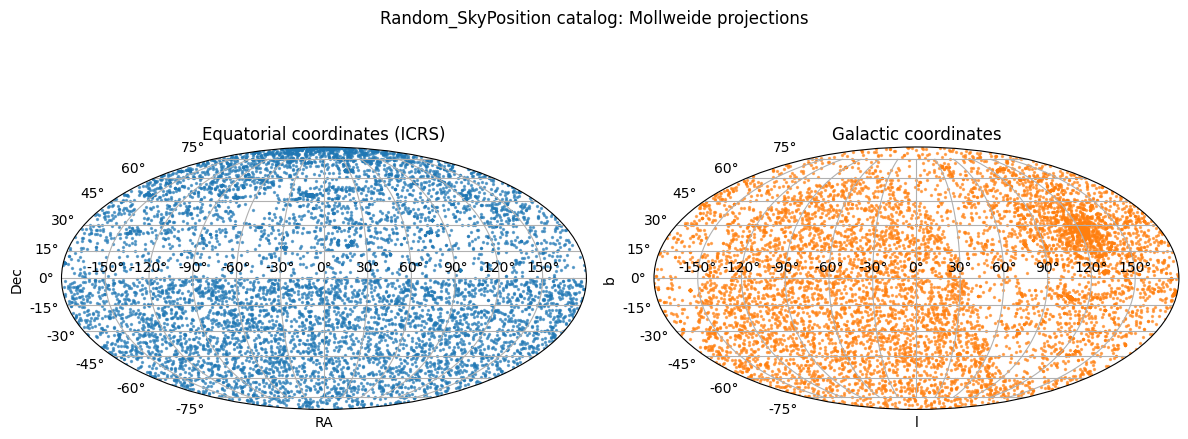

In [3]:
coords_icrs = SkyCoord(
    ra=df_data["RA"].values * u.degree,
    dec=df_data["DEC"].values * u.degree,
    frame="icrs",
)

ra_rad = coords_icrs.ra.wrap_at(180 * u.degree).radian
dec_rad = coords_icrs.dec.radian

coords_gal = coords_icrs.galactic
l_rad = coords_gal.l.wrap_at(180 * u.degree).radian
b_rad = coords_gal.b.radian

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(121, projection="mollweide")
ax.scatter(ra_rad, dec_rad, s=2, alpha=0.6, color="tab:blue")
ax.grid(True)
ax.set_title("Equatorial coordinates (ICRS)")
ax.set_xlabel("RA")
ax.set_ylabel("Dec")

ax2 = fig.add_subplot(122, projection="mollweide")
ax2.scatter(l_rad, b_rad, s=2, alpha=0.6, color="tab:orange")
ax2.grid(True)
ax2.set_title("Galactic coordinates")
ax2.set_xlabel("l")
ax2.set_ylabel("b")

fig.suptitle("Random_SkyPosition catalog: Mollweide projections", y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [4]:
sf_dict, sf_cov_diag_dict, survey_weights, sf_nside = (
    iso.build_survey_selection_functions_improved(
        df_data,
        nside=iso.NSIDE_SF,
        smooth_sigma=iso.SMOOTH_SIGMA,
    )
)

sf_validation = None

if iso.USE_SEL_FUNC:
    validator = iso.SelectionFunctionValidator(
        sf_dict,
        survey_weights,
        sf_nside,
    )

    sf_validation = validator.check_coverage()

    validator.plot_sf(
        save_prefix=iso.FIGURES_DIR / "sf_validation",
    )
else:
    print("Selection-function validation skipped because USE_SEL_FUNC=False.")


--- Survey partitioning disabled ---
USE_SEL_FUNC=False → treating full catalog as one population

--- Building selection functions ---
Unique surveys: 1
        FULLSKY | N=8446 | sigma= 3.0 deg | weight=1.0000

Selection functions successfully built.
Selection-function validation skipped because USE_SEL_FUNC=False.


In [5]:
corr_df, overlap_df = iso.analyze_intersurvey_correlations(df_data)


--- Intersurvey analysis skipped ---
USE_SEL_FUNC=False → no survey partition exists.


In [6]:
df_rand_obs = iso.generate_mixture_catalog_improved(
    n_observed=len(df_data) * iso.N_RAND_FACTOR,
    sf_dict=sf_dict,
    weights=survey_weights,
    nside=sf_nside,
    seed=2000,
    use_poisson=False,
)

theta, w_obs = iso.compute_2pacf(
    df_data,
    df_rand_obs,
)

abs_obs = iso.get_absolute_sum(theta, w_obs)

print("theta bins:", theta.shape)
print("w_obs:", w_obs.shape)
print("abs_obs:", abs_obs.shape)

theta bins: (17,)
w_obs: (17,)
abs_obs: (9,)



JACKKNIFE UNCERTAINTY ESTIMATION
RUN_TAG = nomask_nosf_nosens_bin10

--- Jackknife region assignment ---
NSIDE_JACKKNIFE = 4
Populated regions = 192

--- Jackknife region statistics ---
Objects per region:
min    = 8
median = 39.0
max    = 349


Jackknife regions:   0%|          | 0/192 [00:00<?, ?it/s]

  0%|          | 0/192 [00:00<?, ?it/s]


--- Jackknife summary ---
Leave-one-region samples = 192
Objects kept per sample:
min = 8097
max = 8438
Median sigma[w(theta)] = 8.8119e-03
Median sigma[|<w>|] = 4.2105e-03

--- Covariance correlation diagnostics ---
Mean off-diagonal corr: -0.0458
Median off-diagonal corr: -0.0099
95th percentile corr: 0.2231
Max off-diagonal corr: 0.3697


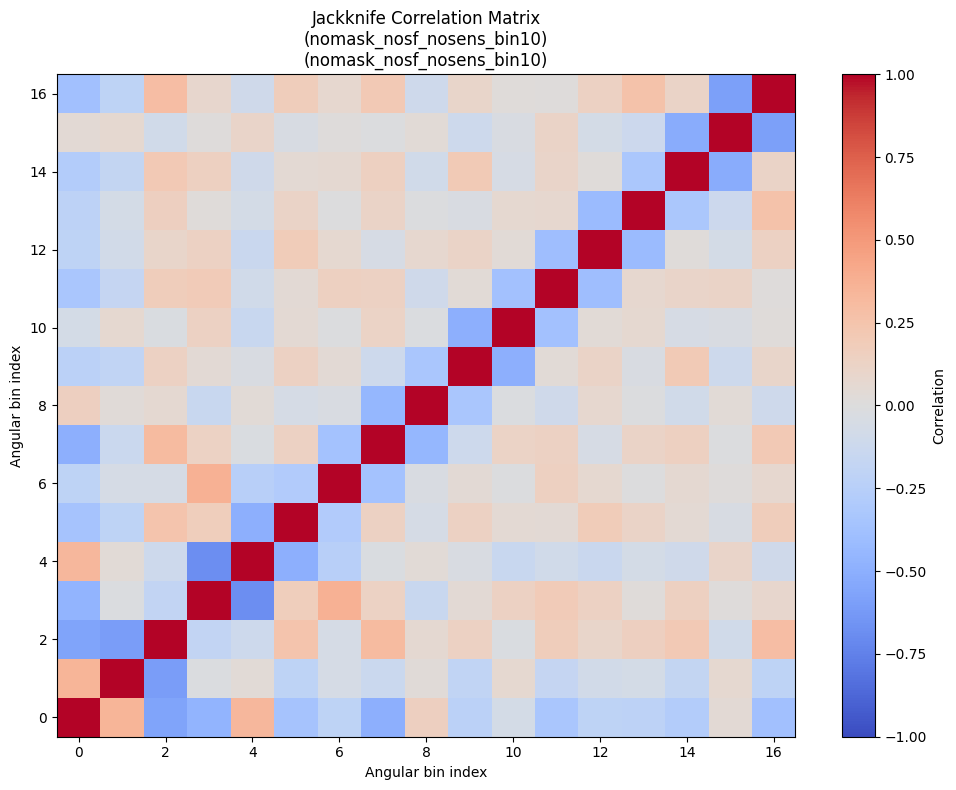


Saved correlation matrix:
  /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Secondary_analysis/outputs/nomask_nosf_nosens_bin10/figures/jk_correlation_matrix.png

BOOTSTRAP UNCERTAINTY ESTIMATION
RUN_TAG = nomask_nosf_nosens_bin10

Bootstrap realizations = 500

Generating fixed random catalog...
Random catalog size = 168920


Bootstrap realizations:   0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]


--- Bootstrap summary ---
Median sigma[w(theta)] = 5.3265e-03
Median sigma[|<w>|] = 4.8453e-03
Max sigma[w(theta)] = 2.9029e-02
Max sigma[|<w>|] = 1.8593e-02

--- Covariance correlation diagnostics ---
Mean off-diagonal corr: -0.0545
Median off-diagonal corr: -0.0408
95th percentile corr: 0.4321
Max off-diagonal corr: 0.6115


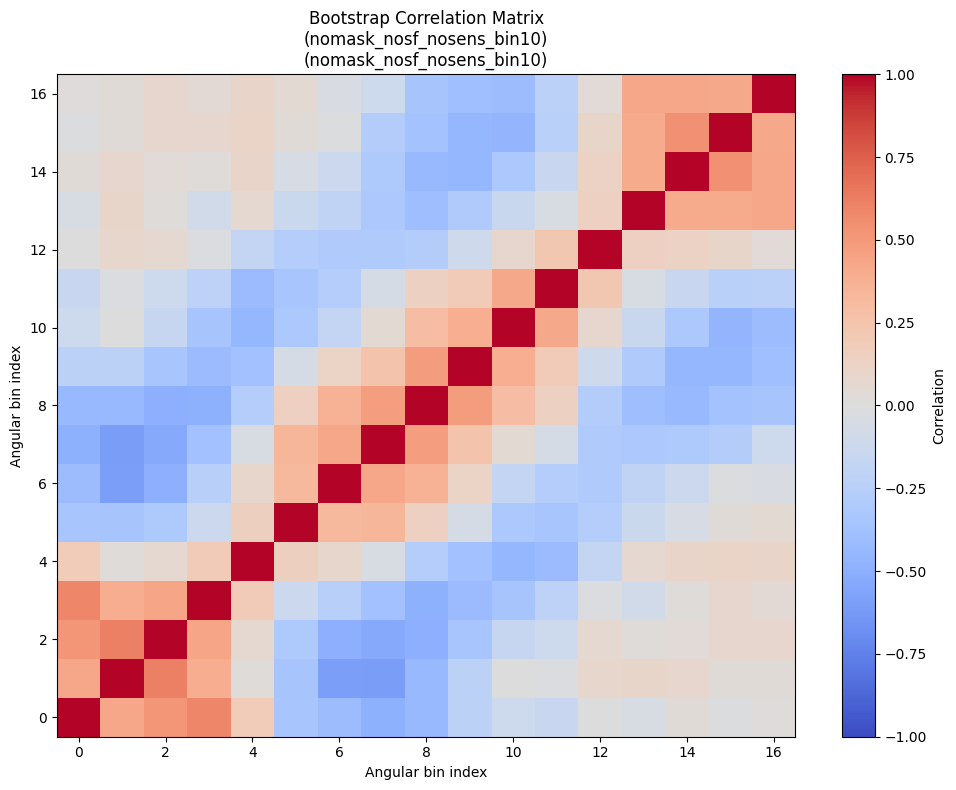


Saved correlation matrix:
  /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Secondary_analysis/outputs/nomask_nosf_nosens_bin10/figures/bootstrap_correlation_matrix.png


In [7]:
jackknife = iso.run_jackknife_errors(
    df_data,
    sf_dict,
    survey_weights,
    sf_nside,
    nside_jackknife=iso.NSIDE_JACKKNIFE,
    min_regions=iso.MIN_JACKKNIFE_REGIONS,
    n_jobs=iso.N_JOBS,
)

bootstrap = iso.run_bootstrap_errors(
    df_data,
    sf_dict,
    survey_weights,
    sf_nside,
    n_bootstrap=iso.N_BOOTSTRAP,
    n_jobs=iso.N_JOBS,
)

In [10]:
all_w_h0, all_abs_h0 = iso.run_ensemble_mocks(
    df_data,
    sf_dict,
    sf_cov_diag_dict,
    survey_weights,
    sf_nside,
    n_ensemble=iso.N_ENSEMBLE,
    n_mocks_per=iso.N_MOCKS_PER_ENSEMBLE,
    perturbation_scale=iso.PERTURBATION_SCALE,
    n_rand_factor=iso.N_RAND_FACTOR,
    n_jobs=iso.N_JOBS,
)

print("all_w_h0:", all_w_h0.shape)
print("all_abs_h0:", all_abs_h0.shape)


--- Generating pure isotropic H0 mocks ---
Total H0 mocks: 1000


H0 ensemble mocks:   0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]


Generated mocks:
  w(theta): (1000, 17)
  |<w>|: (1000, 9)
all_w_h0: (1000, 17)
all_abs_h0: (1000, 9)



GLOBAL ISOTROPY INFERENCE
RUN_TAG = nomask_nosf_nosens_bin10
USE_GAL_MASK = False
USE_SEL_FUNC = False

Max |H0 mean| = 3.2646e-04

--- Covariance correlation diagnostics ---
Mean off-diagonal corr: -0.0573
Median off-diagonal corr: -0.0564
95th percentile corr: -0.0020
Max off-diagonal corr: 0.0451


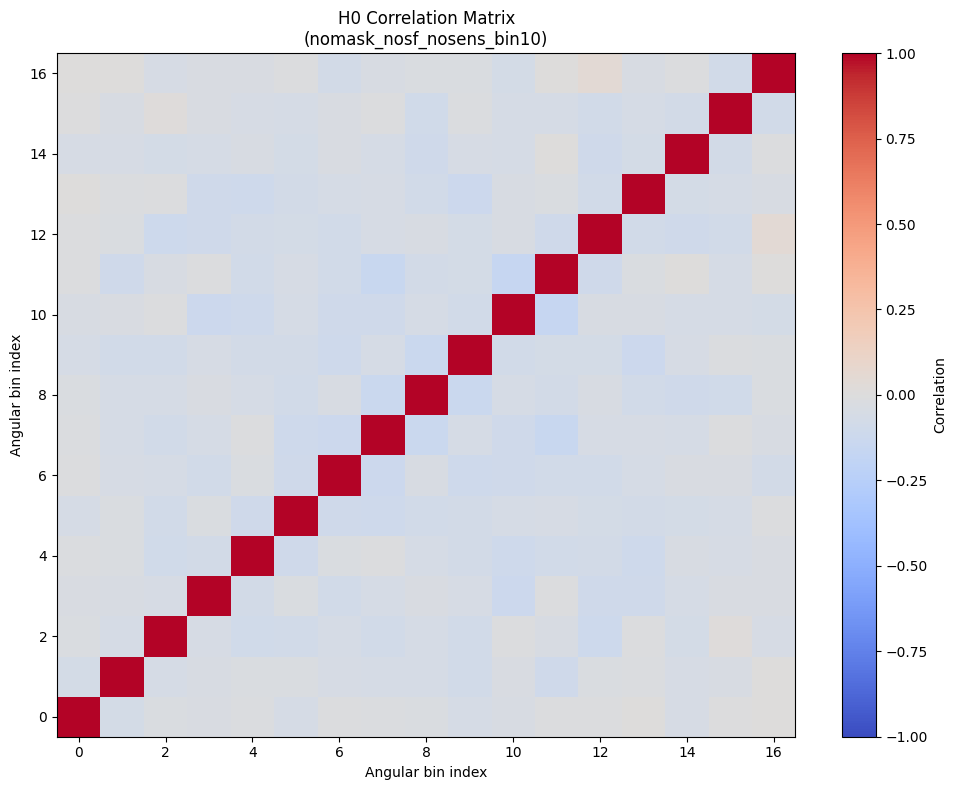


Saved correlation matrix:
  /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Secondary_analysis/outputs/nomask_nosf_nosens_bin10/figures/h0_correlation_matrix.png

MOCK SIMILARITY DIAGNOSTICS
Mocks analyzed: 100
Mean off-diagonal corr: -0.0093
Median off-diagonal corr: -0.0156
95th percentile corr: 0.4046
99th percentile corr: 0.5699
Max off-diagonal corr: 0.8672

Interpretation:
  ⚠ Strong mock correlations detected.
  Covariance estimation may be biased.


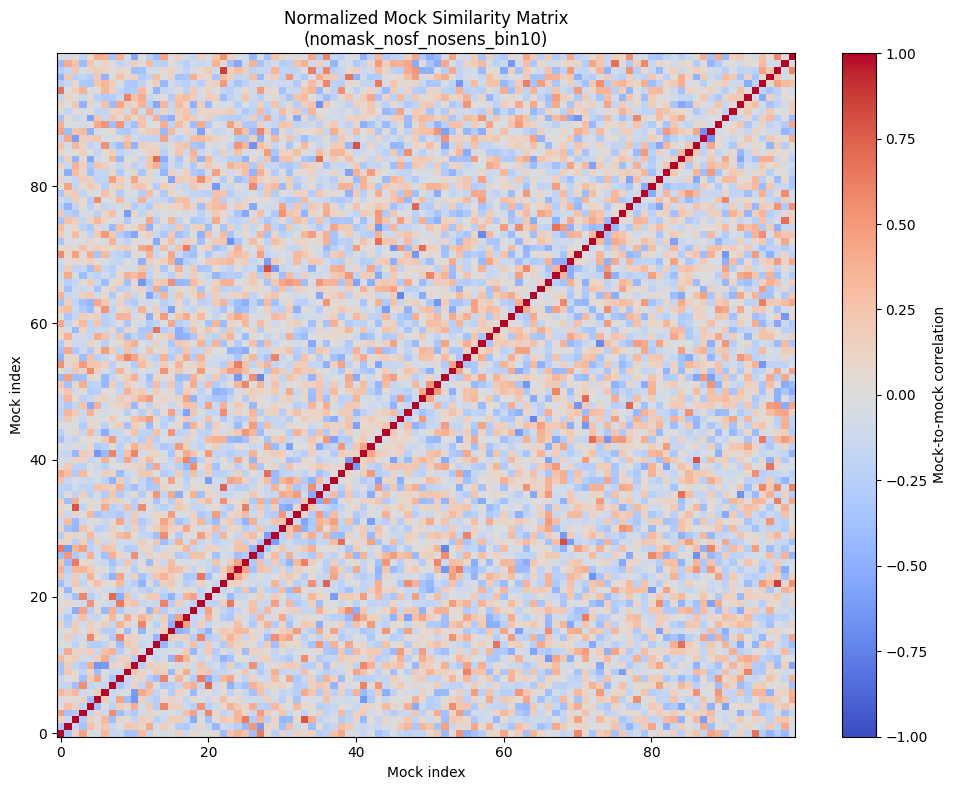


Saved mock similarity matrix:
  /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Secondary_analysis/outputs/nomask_nosf_nosens_bin10/figures/h0_mock_similarity.png


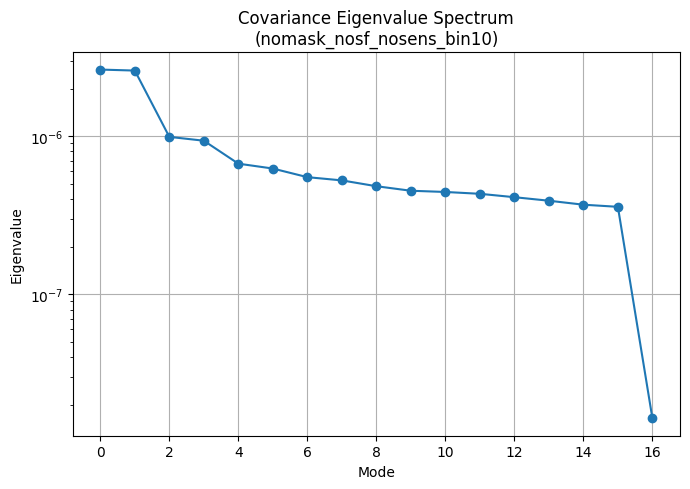


Effective number of modes = 9.03

--- SVD covariance regularization ---
Modes kept: 16/17
Eigenvalue threshold: 1.00e-02
Explained variance kept: 99.87%
SVD condition number: 7.38e+00

--- KS / AD profile tests ---
KS statistic   = 0.58824
KS p-value     = 0.00461
KS empirical p = 0.14486
AD statistic   = 4.64442
AD p-value     = 0.00466
AD empirical p = 0.16084

--- KS / AD profile tests ---
KS statistic   = 1.00000
KS p-value     = 0.00004
KS empirical p = 0.00100
AD statistic   = 8.83538
AD p-value     = 0.00100
AD empirical p = 0.00100

NONPARAMETRIC ISOTROPY DIAGNOSTICS

[w(theta)]
KS p-value          = 0.00461
KS empirical p      = 0.14486
AD p-value          = 0.00466
AD empirical p      = 0.16084

[Absolute sum]
KS p-value          = 0.00004
KS empirical p      = 0.00100
AD p-value          = 0.00100
AD empirical p      = 0.00100

--- Full covariance diagnostic (FRB isotropy (mask_sf_nosens_bin10)) ---
Chi2 = 238695.700
Chi2/dof = 14918.481
p-value (Chi2 analytic) = 0.0000e+00

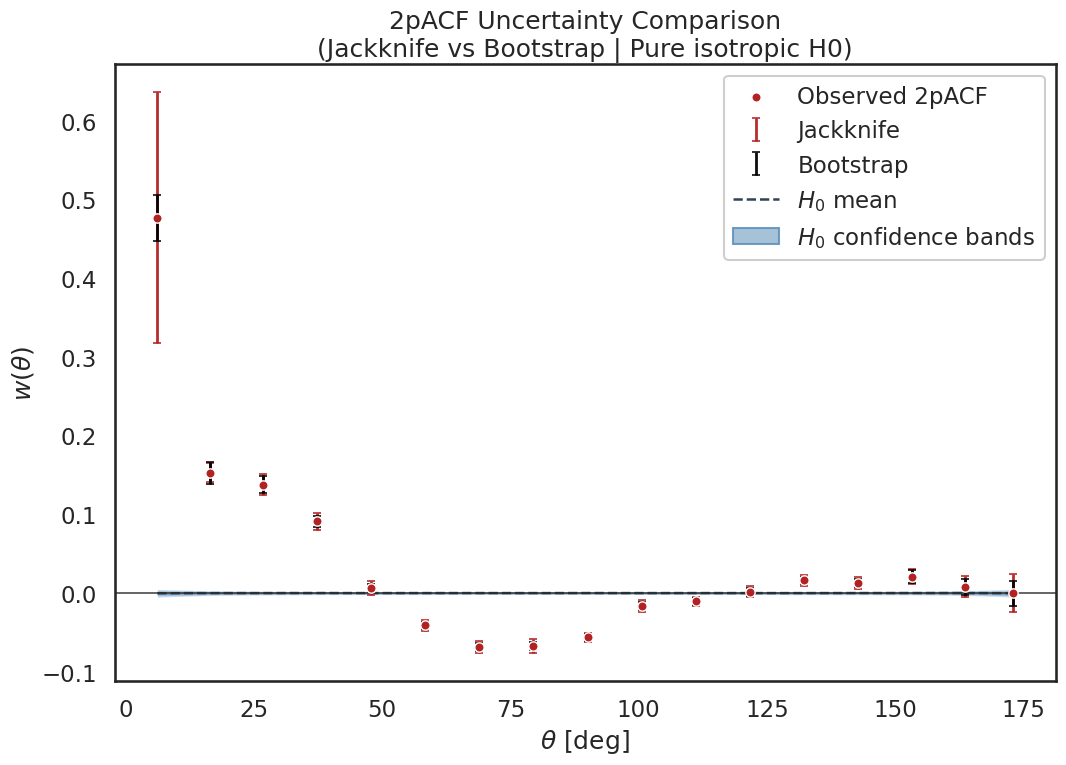

Saved: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Secondary_analysis/outputs/nomask_nosf_nosens_bin10/figures/2pacf_jk_vs_bootstrap.png


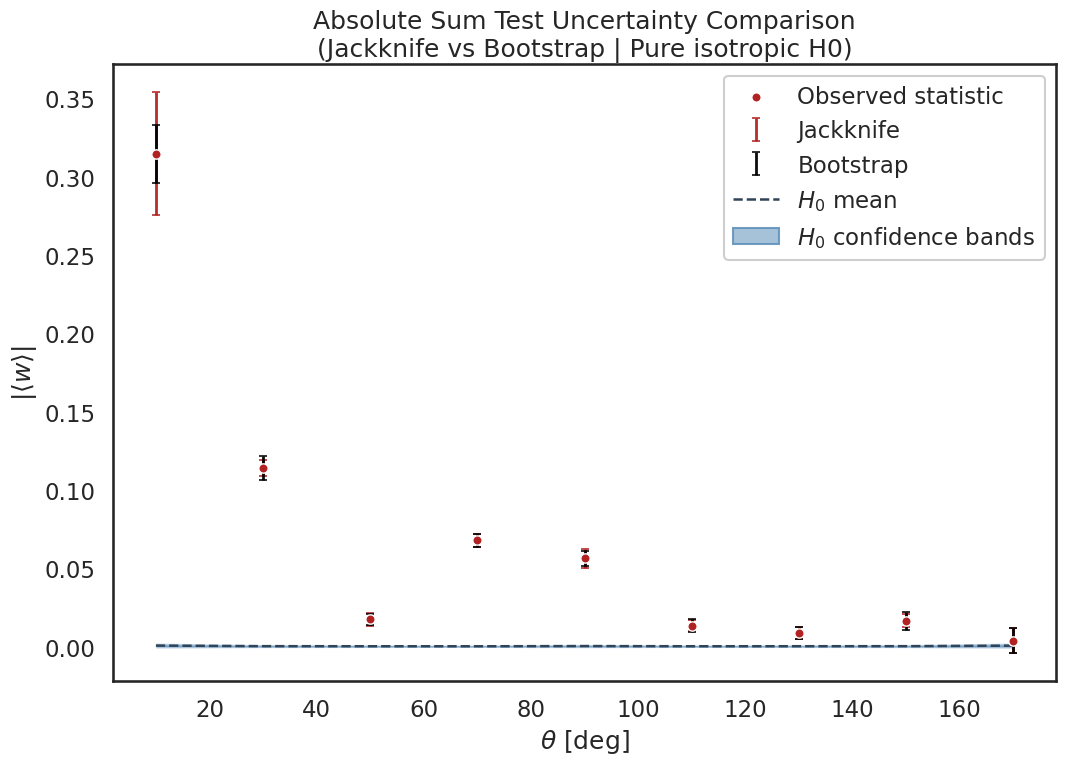

Saved: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Secondary_analysis/outputs/nomask_nosf_nosens_bin10/figures/absolute_anisotropy_jk_vs_bootstrap.png


In [12]:
stats = iso.compute_statistics(
    w_obs,
    abs_obs,
    all_w_h0,
    all_abs_h0,
)

iso.plot_results_jk_vs_bootstrap(
    theta,
    w_obs,
    abs_obs,
    all_w_h0,
    all_abs_h0,
    jackknife,
    bootstrap,
)

In [13]:
sensitivity_results = None

if iso.RUN_SENSITIVITY:
    sensitivity_results = iso.run_empirical_sensitivity_analysis(
        df_data,
        n_jobs=iso.N_JOBS,
    )
else:
    print(
        "Sensitivity scan skipped. "
        "Set RUN_SENSITIVITY=True in frb_isotropy.py to run it."
    )

Sensitivity scan skipped. Set RUN_SENSITIVITY=True in frb_isotropy.py to run it.


In [14]:
chi2_bin_diagnostics, svd_mode_contributions = (
    iso.compute_chi2_diagnostic_tables(
        theta,
        w_obs,
        all_w_h0,
        eigenvalue_cut=iso.SVD_EIGENVALUE_CUT,
    )
)

results = {
    "config": RUN_CONFIG,
    "df_data": df_data,
    "theta": theta,
    "w_obs": w_obs,
    "abs_obs": abs_obs,
    "sf_dict": sf_dict,
    "sf_cov_diag_dict": sf_cov_diag_dict,
    "survey_weights": survey_weights,
    "sf_validation": sf_validation,
    "survey_map_summary": None,
    "intersurvey_corr": corr_df,
    "intersurvey_overlap": overlap_df,
    "jackknife": jackknife,
    "bootstrap": bootstrap,
    "all_w_h0": all_w_h0,
    "all_abs_h0": all_abs_h0,
    "stats": stats,
    "chi2_bin_diagnostics": chi2_bin_diagnostics,
    "chi2_svd_modes": svd_mode_contributions,
    "covariance_matrix": getattr(iso, "LAST_COVARIANCE_MATRIX", None),
    "sensitivity": sensitivity_results,
}

print("Available result keys:")
print(results.keys())



CHI-SQUARE DIAGNOSTICS

Run tag: nomask_nosf_nosens_bin10

Mocks: 1000
Bins: 17
Hartlap factor: 0.98198
SVD modes kept: 16 / 17
Eigenvalue cut: 1.000e-02
Covariance condition number: 1.605e+02
Available result keys:
dict_keys(['config', 'df_data', 'theta', 'w_obs', 'abs_obs', 'sf_dict', 'sf_cov_diag_dict', 'survey_weights', 'sf_validation', 'survey_map_summary', 'intersurvey_corr', 'intersurvey_overlap', 'jackknife', 'bootstrap', 'all_w_h0', 'all_abs_h0', 'stats', 'chi2_bin_diagnostics', 'chi2_svd_modes', 'covariance_matrix', 'sensitivity'])


In [15]:
saved_tables = None

if SAVE_OUTPUTS:
    saved_tables = iso.save_tables(
        results,
        prefix=iso.RUN_TAG,
    )
else:
    print("Output export skipped because SAVE_OUTPUTS=False.")


CHI-SQUARE DIAGNOSTICS

Run tag: nomask_nosf_nosens_bin10

Mocks: 1000
Bins: 17
Hartlap factor: 0.98198
SVD modes kept: 16 / 17
Eigenvalue cut: 1.000e-02
Covariance condition number: 1.605e+02

--- Saved analysis tables ---
sf_validation: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Secondary_analysis/outputs/nomask_nosf_nosens_bin10/tables/sf_validation.csv
intersurvey_corr: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Secondary_analysis/outputs/nomask_nosf_nosens_bin10/tables/intersurvey_corr.csv
intersurvey_overlap: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Secondary_analysis/outputs/nomask_nosf_nosens_bin10/tables/intersurvey_overlap.csv
stats_summary: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Secondary_analysis/outputs/nomask_nosf_nosens_bin10/tables/stats_summary.csv
jackknife_w_errors: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Secondary_analysis/outputs/nomask_nosf_nosens_bin10/tables/jackknife_w_errors.csv
jackknife_abs_errors: /home

In [16]:
print(stats)

print(
    "Median jackknife sigma w(theta):",
    np.median(jackknife.w_err),
)

print(
    "Median jackknife sigma |<w>|:",
    np.median(jackknife.abs_err),
)

print(
    "Median bootstrap sigma w(theta):",
    np.median(bootstrap.w_err),
)

print(
    "Median bootstrap sigma |<w>|:",
    np.median(bootstrap.abs_err),
)

print("SF validation:")
print(results["sf_validation"])

print("Intersurvey correlation:")
print(results["intersurvey_corr"])

print("Intersurvey overlap:")
print(results["intersurvey_overlap"])

print("Jackknife W covariance shape:")
print(results["jackknife"].w_cov.shape)

print("Jackknife absolute covariance shape:")
print(results["jackknife"].abs_cov.shape)

print("Bootstrap W covariance shape:")
print(results["bootstrap"].w_cov.shape)

print("Bootstrap absolute covariance shape:")
print(results["bootstrap"].abs_cov.shape)

TestStatistics(chi2=238695.70001996722, chi2_red=14918.481251247951, p_chi2=0.0, p_empirical=0.000999000999000999, p_empirical_floor=0.000999000999000999, sigma_equiv=3.0905291379252677, chi2_svd=206872.75335243397, chi2_svd_red=12929.547084527123, p_chi2_svd=0.0, p_svd_empirical=0.000999000999000999, p_svd_empirical_floor=0.000999000999000999, sigma_svd_equiv=3.0905291379252677, global_tension=108.90790015776146, ks_w_stat=0.5882352941176471, ks_w_pvalue=0.00461056021696754, ks_w_empirical_p=0.14485514485514486, ad_w_stat=4.644422581766892, ad_w_pvalue=0.004664122467174318, ad_w_empirical_p=0.16083916083916083, ks_abs_stat=1.0, ks_abs_pvalue=4.11353352529823e-05, ks_abs_empirical_p=0.000999000999000999, ad_abs_stat=8.835378466066038, ad_abs_pvalue=0.001, ad_abs_empirical_p=0.000999000999000999, abs_observed_stat=0.11581110197491996, abs_empirical_p=0.000999000999000999, hartlap_factor=0.9819819819819819, covariance_rank=17, covariance_condition=160.5259443288973, n_eff=np.float64(9.02

In [17]:
if RUN_TOP_SURVEY_MAPS and iso.USE_SEL_FUNC:
    survey_map_summary = iso.plot_top_survey_maps(
        df_data,
        sf_dict,
        survey_weights,
        sf_nside,
        max_surveys=12,
        output_prefix=iso.FIGURES_DIR / "survey_maps",
    )

    results["survey_map_summary"] = survey_map_summary
else:
    print(
        "Top survey maps skipped. "
        "Set RUN_TOP_SURVEY_MAPS=True to generate them."
    )

Top survey maps skipped. Set RUN_TOP_SURVEY_MAPS=True to generate them.
